In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (1).csv


In [ ]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [ ]:
print("Shape :", df.shape)
print()

print(df.info())
print()

print(df.columns)

Shape : (2640, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Uni

In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [ ]:
print("Regions")
print(df["Region"].value_counts())

print("\nModels")
print(df["Model"].value_counts())

print("\nSource Type")
print(df["Source_Type"].value_counts())

Regions
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Models
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source Type
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


In [ ]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [ ]:
df = df.sort_values("Date")
df.reset_index(drop=True, inplace=True)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


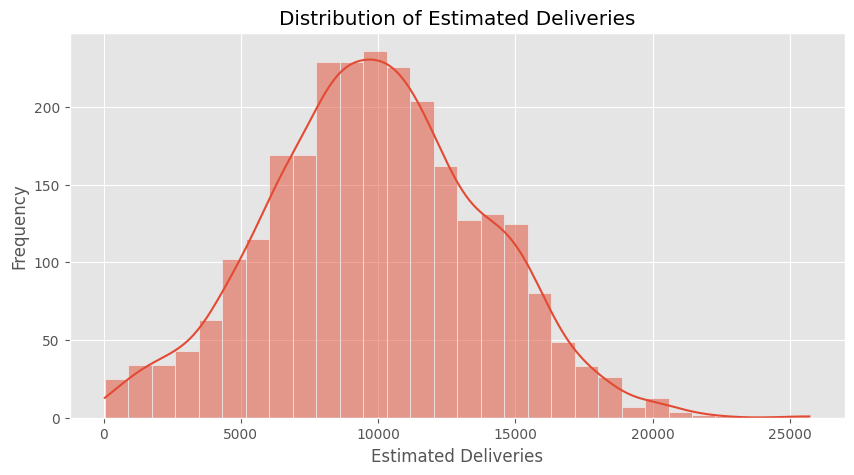

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Estimated_Deliveries"],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")

plt.show()

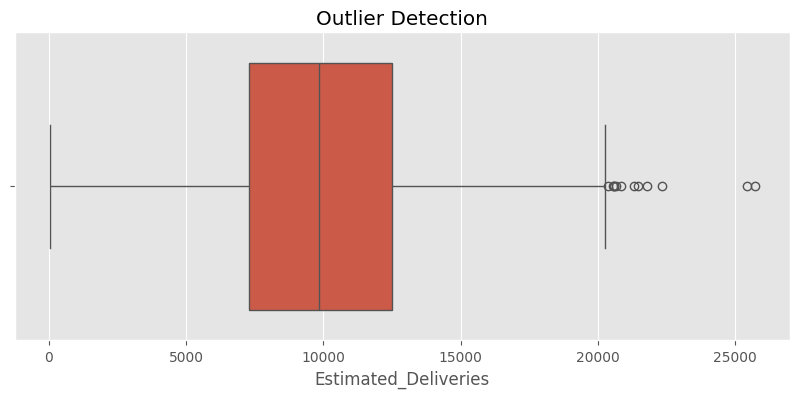

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["Estimated_Deliveries"]
)

plt.title("Outlier Detection")

plt.show()

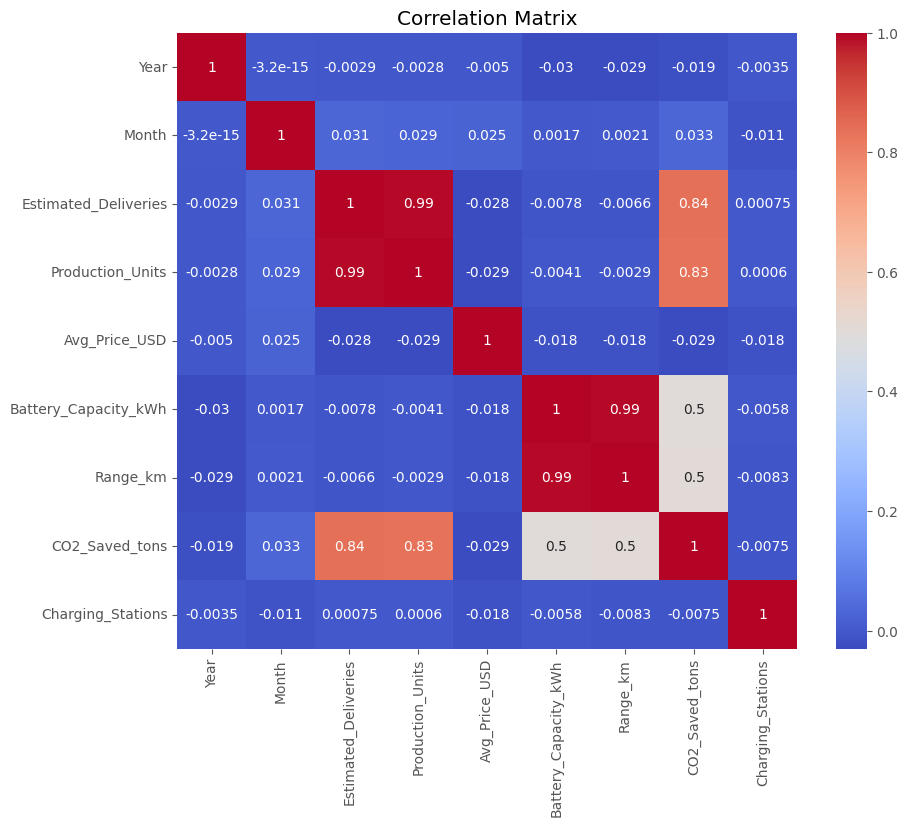

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

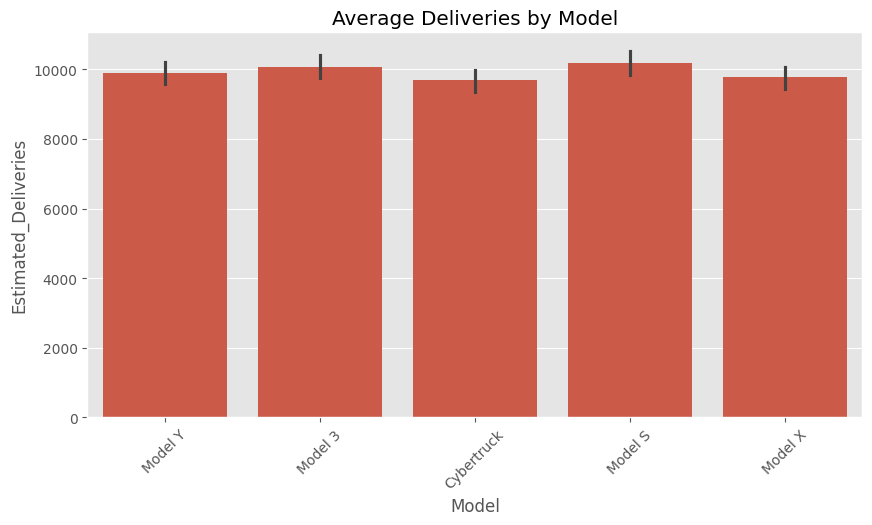

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries",
    estimator=np.mean
)

plt.title("Average Deliveries by Model")

plt.xticks(rotation=45)

plt.show()

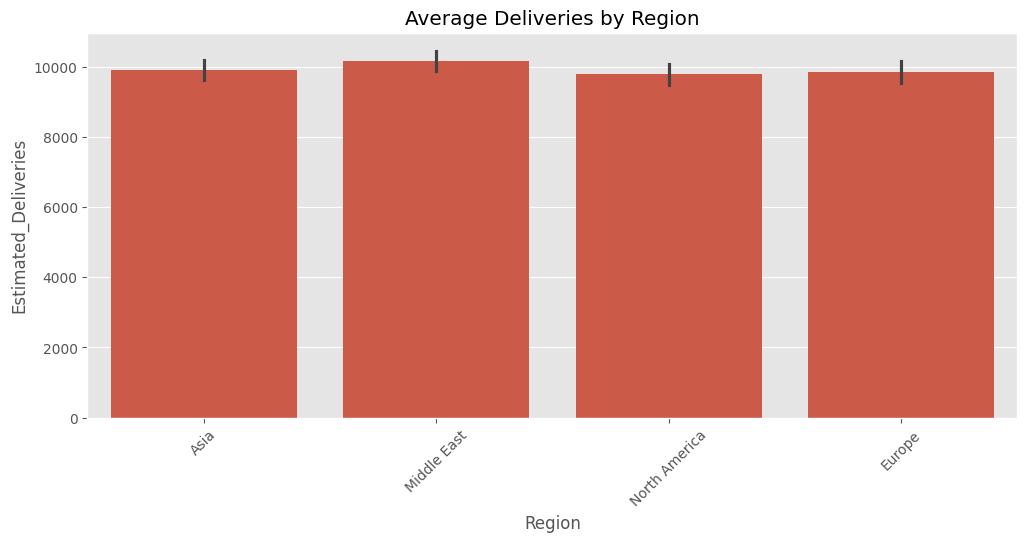

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries",
    estimator=np.mean
)

plt.title("Average Deliveries by Region")

plt.xticks(rotation=45)

plt.show()

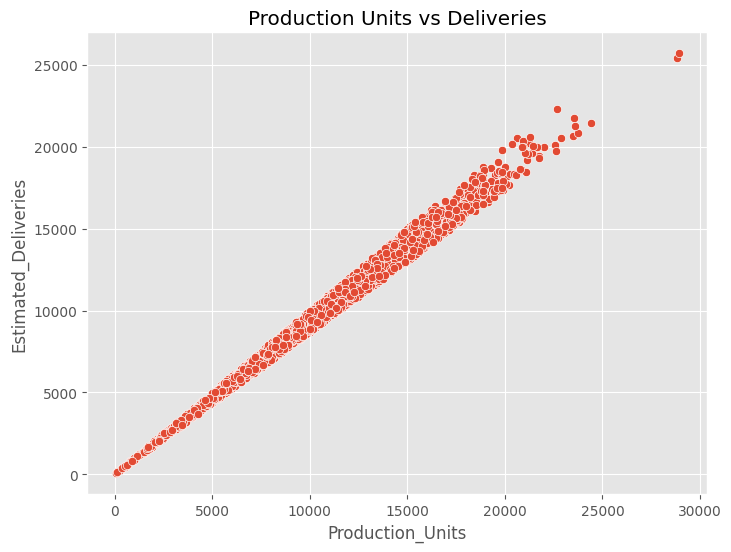

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Deliveries")

plt.show()

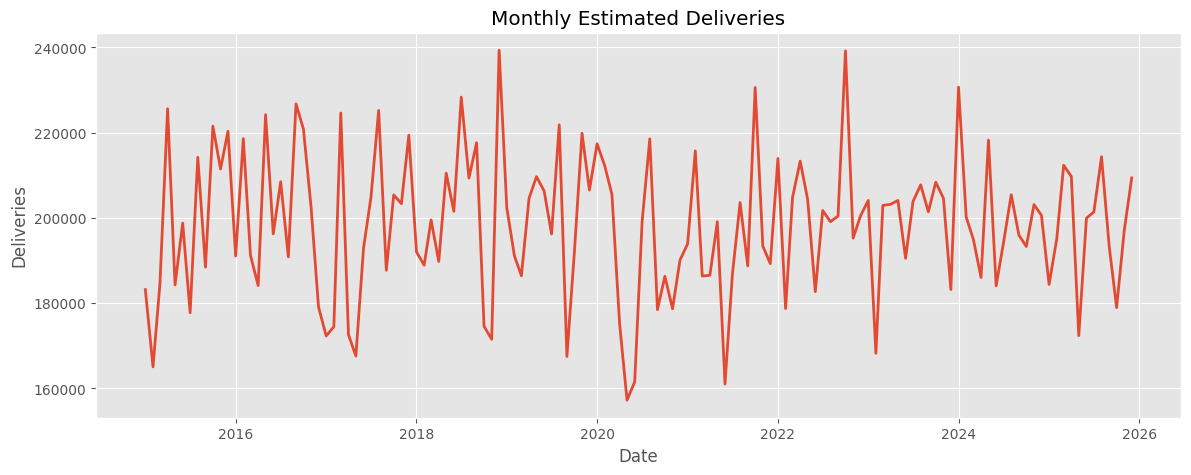

In [ ]:
monthly = df.groupby("Date")["Estimated_Deliveries"].sum()

plt.figure(figsize=(14,5))

plt.plot(
    monthly.index,
    monthly.values,
    linewidth=2
)

plt.title("Monthly Estimated Deliveries")

plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

In [ ]:
# Extract additional date features

df["Quarter"] = df["Date"].dt.quarter
df["Month_Name"] = df["Date"].dt.month_name()

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Name
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,January
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,January
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,January
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,January
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,January


In [ ]:
df["Lag_1"] = df["Estimated_Deliveries"].shift(1)
df["Lag_2"] = df["Estimated_Deliveries"].shift(2)
df["Lag_3"] = df["Estimated_Deliveries"].shift(3)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Name,Lag_1,Lag_2,Lag_3
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,January,NaN,NaN,NaN
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,January,12446.0,NaN,NaN
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,January,11446.0,12446.0,NaN
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,January,8803.0,11446.0,12446.0
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,January,6367.0,8803.0,11446.0


In [ ]:
df["Rolling_Mean_3"] = df["Estimated_Deliveries"].rolling(window=3).mean()

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Name,Lag_1,Lag_2,Lag_3,Rolling_Mean_3
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,January,NaN,NaN,NaN,NaN
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,January,12446.0,NaN,NaN,NaN
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,January,11446.0,12446.0,NaN,10898.333333
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,January,8803.0,11446.0,12446.0,8872.000000
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,January,6367.0,8803.0,11446.0,7988.333333


In [ ]:
df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

print(df.shape)

(2637, 19)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()
le_month = LabelEncoder()

df["Region"] = le_region.fit_transform(df["Region"])
df["Model"] = le_model.fit_transform(df["Model"])
df["Source_Type"] = le_source.fit_transform(df["Source_Type"])
df["Month_Name"] = le_month.fit_transform(df["Month_Name"])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Name,Lag_1,Lag_2,Lag_3,Rolling_Mean_3
0,2015,1,3,0,6367,6802,104962.32,82,459,438.37,0,9170,2015-01-01,1,4,8803.0,11446.0,12446.0,8872.000000
1,2015,1,0,1,8795,9165,87988.73,82,456,601.58,2,12626,2015-01-01,1,4,6367.0,8803.0,11446.0,7988.333333
2,2015,1,1,0,2161,2465,112637.91,120,695,225.28,0,14062,2015-01-01,1,4,8795.0,6367.0,8803.0,5774.333333
3,2015,1,3,2,11986,13302,91906.09,82,457,821.64,0,4871,2015-01-01,1,4,2161.0,8795.0,6367.0,7647.333333
4,2015,1,1,3,8833,8878,113652.43,82,461,610.80,2,10950,2015-01-01,1,4,11986.0,2161.0,8795.0,7660.000000


In [ ]:
X = df.drop(columns=["Estimated_Deliveries", "Date"])

y = df["Estimated_Deliveries"]

print(X.shape)
print(y.shape)

(2637, 17)
(2637,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2109, 17)
(528, 17)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 :", r2_score(y_test, lr_pred))

Linear Regression
MAE : 9.975158746149674e-12
RMSE : 1.2492391375222087e-11
R2 : 1.0


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [ ]:
print("Decision Tree")

print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 :", r2_score(y_test, dt_pred))

Decision Tree
MAE : 416.9128787878788
RMSE : 560.1378144815088
R2 : 0.9784869637882583


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 :", r2_score(y_test, rf_pred))

Random Forest
MAE : 318.45409090909095
RMSE : 400.88199905305396
R2 : 0.9889809276662915


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ]
})

results.sort_values("R2 Score", ascending=False)

,Model,R2 Score,RMSE
0,Linear Regression,1.000000,1.249239e-11
2,Random Forest,0.988981,4.008820e+02
1,Decision Tree,0.978487,5.601378e+02


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
4,Production_Units,0.990305
8,CO2_Saved_tons,0.001620
5,Avg_Price_USD,0.000914
7,Range_km,0.000870
10,Charging_Stations,0.000806
15,Lag_3,0.000803
16,Rolling_Mean_3,0.000788
13,Lag_1,0.000783
14,Lag_2,0.000709
0,Year,0.000531


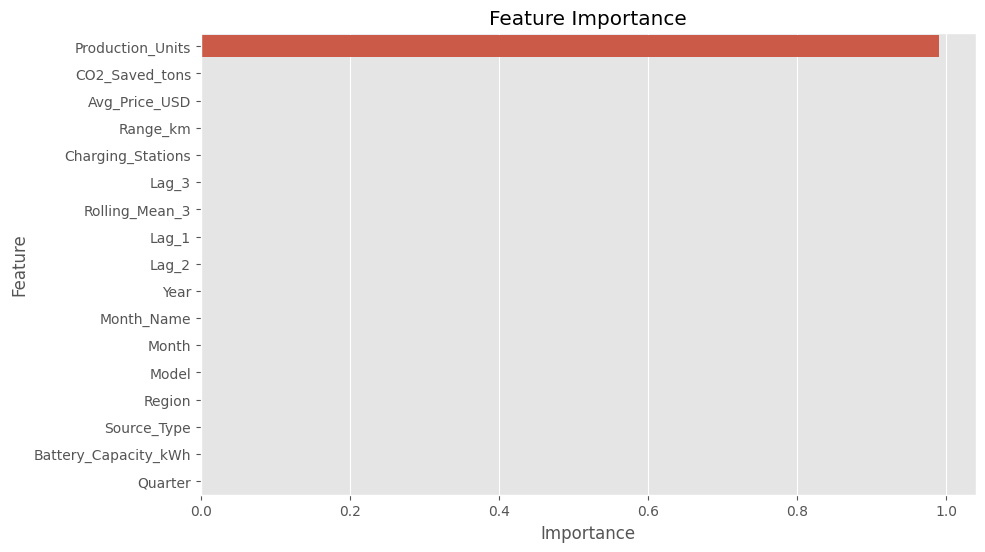

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Score:
0.9876001710853144


In [ ]:
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)

print("Optimized Random Forest")

print("MAE :", mean_absolute_error(y_test, best_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R2 :", r2_score(y_test, best_pred))

Optimized Random Forest
MAE : 316.1937878787879
RMSE : 398.15297517787354
R2 : 0.9891304427634411


In [ ]:
import joblib

joblib.dump(best_rf, "best_random_forest_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
!pip -q install statsmodels

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

monthly_series = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
)

monthly_series.head()

,Estimated_Deliveries
Date,
2015-01-01,150485
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


In [ ]:
arima_model = ARIMA(
    monthly_series,
    order=(2,1,2)
)

arima_result = arima_model.fit()

print(arima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(2, 1, 2)   Log Likelihood               -1490.717
Date:                  Fri, 26 Jun 2026   AIC                           2991.434
Time:                          19:16:46   BIC                           3005.810
Sample:                      01-01-2015   HQIC                          2997.276
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3628      0.064     21.263      0.000       1.237       1.488
ar.L2         -0.4464      0.070     -6.398      0.000      -0.583      -0.310
ma.L1         -1.9075      0.109    

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
forecast = arima_result.forecast(steps=12)

forecast

,predicted_mean
2026-01-01,205589.213008
2026-02-01,203566.317504
2026-03-01,202506.390206
2026-04-01,201964.813301
2026-05-01,201699.837139
2026-06-01,201580.454028
2026-07-01,201536.028160
2026-08-01,201528.770472
2026-09-01,201538.709334
2026-10-01,201555.494030


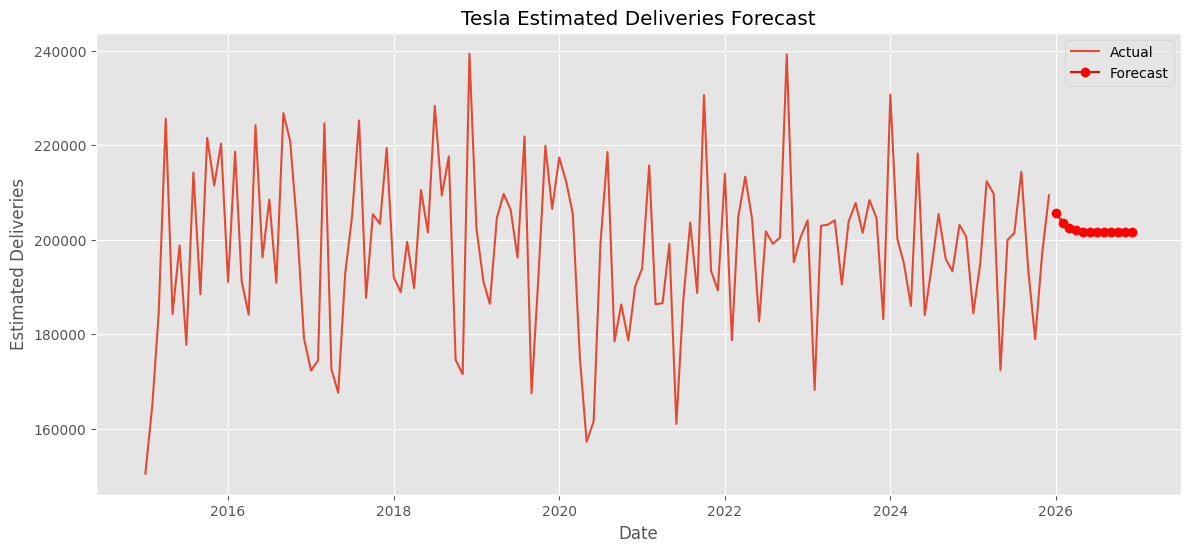

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_series.index,
    monthly_series.values,
    label="Actual"
)

future_dates = pd.date_range(
    start=monthly_series.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

plt.plot(
    future_dates,
    forecast,
    color="red",
    marker="o",
    label="Forecast"
)

plt.title("Tesla Estimated Deliveries Forecast")

plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()

In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Optimized Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, best_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, best_pred))
    ]
})

final_results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score,RMSE
0,Linear Regression,1.000000,1.249239e-11
3,Optimized Random Forest,0.989130,3.981530e+02
2,Random Forest,0.988981,4.008820e+02
1,Decision Tree,0.978487,5.601378e+02


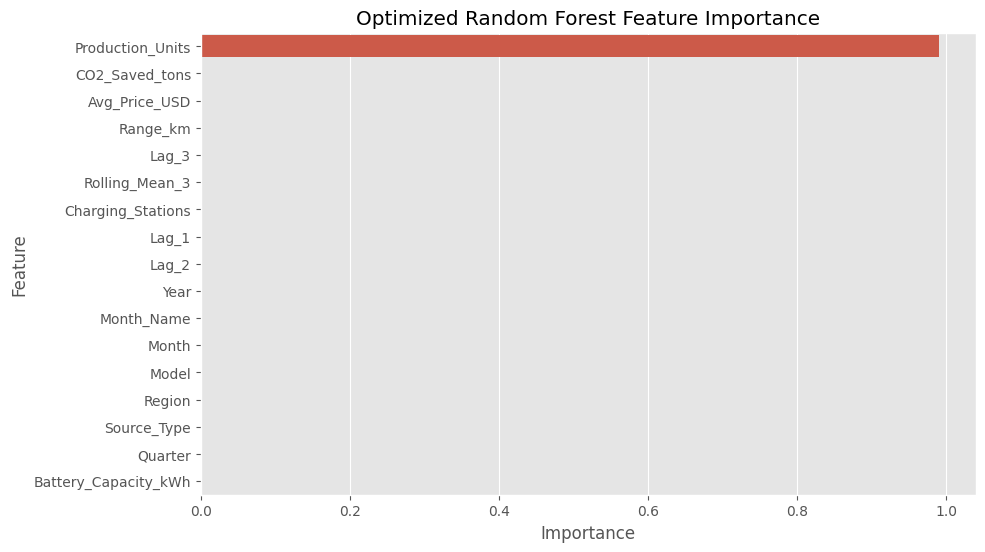

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Optimized Random Forest Feature Importance")

plt.show()

In [ ]:
from google.colab import files

files.download("best_random_forest_model.pkl")